In [14]:
import random
import torch
from d2l import torch as d2l


def synthetic_data(w, b, num_examples):  #@save
    """Generate y = Xw + b + noise."""
    X = torch.normal(0, 1, (num_examples, len(w)))
    print(X.shape)
    print(X)
    y = torch.matmul(X, w) + b
    print(y.shape)
    print(y)
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

torch.Size([1000, 2])
tensor([[ 0.6244, -0.1721],
        [ 0.1815, -0.2384],
        [-1.2291,  0.0018],
        ...,
        [-0.5271,  0.0542],
        [-1.0954,  0.0431],
        [-0.8643,  0.5410]])
torch.Size([1000])
tensor([ 6.0341e+00,  5.3734e+00,  1.7354e+00,  5.4024e+00,  4.2928e+00,
         8.0715e+00,  1.2625e+00,  7.7255e+00, -1.4926e+00,  7.4134e+00,
         2.8627e+00,  1.8128e-01,  3.0454e+00, -5.8833e-01,  2.1765e+00,
         1.2949e-02,  7.2905e+00,  8.2278e+00,  1.1182e+01,  5.2341e+00,
         2.1643e+00,  1.0867e+01,  4.2617e+00,  2.6345e+00,  6.4020e+00,
         5.7501e+00,  9.1038e+00,  3.4329e+00,  6.3293e+00,  8.5295e+00,
         4.0846e+00,  5.7878e+00,  3.6235e+00, -1.5660e+00,  1.2321e+00,
         6.1864e+00, -5.5751e+00,  5.0285e+00,  1.0226e+01,  3.9988e+00,
         4.1901e+00,  6.5963e+00, -1.0119e+00,  8.8826e+00,  4.1268e+00,
        -2.6729e+00, -2.2934e+00,  3.9689e+00,  1.0984e+01,  1.7834e+00,
         1.2416e+00,  4.7645e+00,  5.4587e+00, 

In [11]:
print('features:', features[0],'\nlabel:', labels[0])

features: tensor([-1.1112,  0.1900]) 
label: tensor([1.3278])


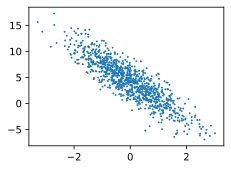

In [12]:
d2l.set_figsize()
d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1);

In [19]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # 这些样本是随机读取的，没有特定的顺序
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

batch_size = 10
for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[-0.0292, -0.7984],
        [ 0.2733, -0.2432],
        [ 0.4381, -0.6115],
        [-0.8845,  1.1500],
        [ 0.5454, -0.7903],
        [-0.4698,  0.1313],
        [ 0.1672, -1.2808],
        [ 1.5096,  0.8109],
        [-0.7797, -0.9616],
        [-1.4004, -0.0256]]) 
 tensor([[ 6.8584],
        [ 5.5635],
        [ 7.1445],
        [-1.4768],
        [ 7.9862],
        [ 2.8027],
        [ 8.9003],
        [ 4.4581],
        [ 5.9082],
        [ 1.4822]])


In [20]:
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

def linreg(X, w, b):  #@save
    """线性回归模型"""
    return torch.matmul(X, w) + b

def squared_loss(y_hat, y):  #@save
    """均方损失"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

def sgd(params, lr, batch_size):  #@save
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

In [21]:
lr = 0.03  # 学习率
num_epochs = 3  # 训练周期
net = linreg  # 模型
loss = squared_loss  # 损失函数

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)  # l 的形状是 (batch_size, 1)
        # 因为 l 的形状是 (batch_size, 1)，而不是一个标量。l 中的所有元素被加到一起，
        # 并以此计算关于 [w, b] 的梯度
        l.sum().backward()
        sgd([w, b], lr, batch_size)  # 使用参数的梯度更新参数
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')


epoch 1, loss 0.031130
epoch 2, loss 0.000107
epoch 3, loss 0.000050


In [22]:
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

w的估计误差: tensor([6.3288e-04, 4.3154e-05], grad_fn=<SubBackward0>)
b的估计误差: tensor([0.0007], grad_fn=<RsubBackward1>)
